# Assignment 4: Optimizing Logistic Regression

In [34]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score

In this assignment, you will continue practicing the fourth step of the machine learning life cycle and train logistic regression models that will be used to solve a classification problem.  You will build many variants, each one with a different value of the $C$ hyperparameter, which governs the amount of regularization used. Regularization is a process where we add a "penalty" to the original log loss function. This penalty is a function of the magnitudes of the weights learned in the Logistic Regression. The following shows the regularized log loss using what is called "L2" regularization.<br><br> 

<center>$Regularized \ LogLoss = -\frac{1}{N} \sum\limits_{i=1}^N (y_ilog(P_i)+(1-y_i)log(1-P_i))+\frac{1}{C} \sum\limits_{j=1}^m w_j^2$</center><br><br>


With L2 regularization, the penalty is the sum of the squares of the weights scaled by a constant $1/C$. When the hyperparameter $C$ is large, we reduce the weight of the penalty, which results in less regularization. You will build Logistic regressions with different values of $C$ and will check how this impacts the log loss.


You will complete the following tasks:

1. Build your DataFrame and define your ML problem:
    * Load the "cell2cell" data set into a DataFrame
    * Define the label - what are you predicting?
    * Identify features
3. Create labeled examples from the data set
4. Split the data into training and test data sets
5. Train logistic regression classifiers and evaluate their performances:
    * Fit logistic regression models to the training data using different hyperparameter values per classifier
    * Evaluate the accuracy of each model's predictions
    * Plot and analyize the resulting log loss and accuracy scores

## Part 1. Build Your DataFrame and Define Your ML Problem

#### Load a Data Set and Save it as a Pandas DataFrame

We will work with the "cell2celltrain" data set. This version of the data set has been preprocessed and is ready for modeling.

In [35]:
# Do not remove or edit the line below:
filename = os.path.join(os.getcwd(), "data", "cell2celltrain.csv")

**Task**: Load the data and save it to DataFrame `df`.

In [36]:
# YOUR CODE HERE
df = pd.read_csv(filename)

#### Define the Label

This is a binary classification problem in which we will predict customer churn. The label is the `Churn` column.

#### Identify Features

To implement a Logistic Regression model, we must use only the numeric columns. 


<b>Task</b>: Use the Pandas DataFrame <code>select_dtypes()</code> method to obtain all of names of columns that have a dtype of "float64." Save the result to a list named `feature_list`. 

In [37]:
# YOUR CODE HERE
feature_list = df.select_dtypes(include='float64').columns.tolist()
len(feature_list)

35

## Part 2. Create Labeled Examples from the Data Set 

Our data is fully prepared for modeling. We can now create labeled examples from DataFrame `df`.

<b>Task</b>: Obtain the feature columns from DataFrame `df` and assign to `X`. Obtain the label column from DataFrame `df` and assign to `y`.

You should have 51047 labeled examples. Each example contains 35 features and one label.

In [38]:
# YOUR CODE HERE
y=df['Churn']
X=df[feature_list]

X.shape

(51047, 35)

## Part 3. Create Training and Test Data Sets

<b>Task</b>: Create training and test data sets out of the labeled examples. Save the results to variables `X_train, X_test, y_train, y_test`.

In [39]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=123)

<b>Task</b>: Check the dimensions of the training and test data sets.

In [40]:
# YOUR CODE HERE
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(34201, 35)
(34201,)
(16846, 35)
(16846,)


## Part 4. Train a Logistic Regression Classifier and Evaluate the Model

The code cell below contains a function definition `train_test_LR()`. 

Inspect the function definition `train_test_LR(X_train, X_test, y_train, y_test, c=1)`. The function expects the training and test data sets, as well as a value for hyperparameter $C$. Note that we supplied the value of 1 for $C$ by default.

<b>Task:</b> Complete the function to make it work.

This function should:
1. train a Logistic Regression model on the training data
2. test the resulting model on the test data
3. compute and return two items:
    * the log loss of the resulting probability predictions on the test data 
    * the accuracy score of the resulting predicted class labels on the test data


You will use the scikit-learn [```LogisticRegression``` class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) and will provide the arguments `C=c` when creating the model object.




In [41]:
def train_test_LR(X_train, y_train, X_test, y_test, c=1):
    '''
    Fit a Linear Regression classifier to the training data X_train, y_train.
    Return the loss and accuracy of resulting predictions on the test set.
    Parameters:
        C = Factor that controls how much regularization is applied to the model.
    '''
    
    # YOUR CODE HERE
    model = LogisticRegression(C=c)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test,y_pred)
    log_loss_value = log_loss(y_test, y_pred_proba)
    return [acc,log_loss_value]

### Train a Model and Analyze the Results

<b>Task:</b> Use your function `train_test_LR()` to train one Logistic Regression classifier with the default value of hyperparameter C (`c=1`). Print the resulting log loss and accuracy score.

In [42]:
# YOUR CODE HERE
print(train_test_LR(X_train, y_train, X_test, y_test))

[0.7106137955597768, 0.58636977015501]


## Part 5. Train on Different Hyperparameter Values and Analyze the Results

Now we will adjust the $C$ regularization hyperparameter to check its impact on the model's log loss and accuracy. Hyperparameter `C` stands for the inverse of regularization strength. Smaller values specify stronger regularization and a simpler model. Larger values specify weaker regularization and a more complex model.<br>

The code cell below creates a list `cs` of twenty values of $C$.  Every item in the list has a value $10^i$ for every integer $i$ in the output of `range(-10,10)`. Run the code cell below and inspect the different values of $C$.

In [43]:
cs = [10**i for i in range(-10,10)]
cs

[1e-10,
 1e-09,
 1e-08,
 1e-07,
 1e-06,
 1e-05,
 0.0001,
 0.001,
 0.01,
 0.1,
 1,
 10,
 100,
 1000,
 10000,
 100000,
 1000000,
 10000000,
 100000000,
 1000000000]

<b>Task</b>: In the code cell below, loop over list `cs` and train and evaluate a different Logistic Regression model for every value of $C$. Use your function `train_test_LR()`. Print the resulting log loss and accuracy scores per model.

We will want to create visualizations that plot the resulting log loss and accuracy score for every value of hyperparameter $C$. Considering this, save the resulting log loss values and accuracy scores that your function returns to two different lists. You will use these lists to create plots later.

In [44]:
# YOUR CODE HERE
ll=[]
acc=[]
for x in cs:
    returnedlist = train_test_LR(X_train, y_train, X_test, y_test, x)
    a = returnedlist[0]
    l = returnedlist[1]
    print('c='+str(x)+', acc='+str(a)+', log_loss='+str(l))
    ll.append(l)
    acc.append(a)

c=1e-10, acc=0.7110293244687166, log_loss=0.601230791100343
c=1e-09, acc=0.7110293244687166, log_loss=0.6012305713944056
c=1e-08, acc=0.7110293244687166, log_loss=0.6012283739988561
c=1e-07, acc=0.7110293244687166, log_loss=0.6012064851118623
c=1e-06, acc=0.7110293244687166, log_loss=0.6009954268207465
c=1e-05, acc=0.7110293244687166, log_loss=0.5993903708877584
c=0.0001, acc=0.7110293244687166, log_loss=0.593491210921004
c=0.001, acc=0.7118603822865962, log_loss=0.5872716906107756
c=0.01, acc=0.7110293244687166, log_loss=0.5862762379358576
c=0.1, acc=0.7104950730143654, log_loss=0.5863534069878181
c=1, acc=0.7106137955597768, log_loss=0.58636977015501
c=10, acc=0.7106137955597768, log_loss=0.586370800996758
c=100, acc=0.7106137955597768, log_loss=0.5863707876296416
c=1000, acc=0.7106137955597768, log_loss=0.5863708025197696
c=10000, acc=0.7106137955597768, log_loss=0.586370804070291
c=100000, acc=0.7106137955597768, log_loss=0.5863708042259672
c=1000000, acc=0.7106137955597768, log_lo

Now let's visualize the results. 

Before we create plots, let's reformat the hyperparameter values in list `cs` so that they can be easily visualized in our plots. We will take the log 10 of the hyperparameter values and save it to a new list called `cs_log10`. Let's take a look at the original values and transformed values:
 

In [45]:
cs_log10 = np.log10(cs)

print(cs)
print(cs_log10)

[1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
[-10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.]



#### Plot Log Loss

<b>Task:</b> Create a `seaborn` lineplot to plot the resulting log loss for every value of hyperparameter $C$. The hyperparameter $C$ should be plotted on the x axis and the log loss should be plotted on the y axis. Label the x and y axes accordingly. Use the transformed values of hyperparameter $C$ contained in the list `cs_log10`.

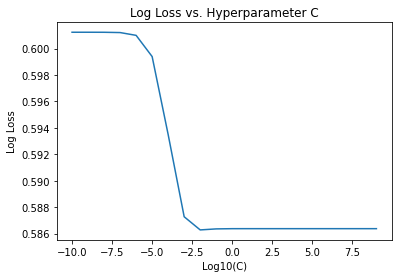

In [46]:
# YOUR CODE HERE
sns.lineplot(x=cs_log10,y=ll)
plt.xlabel('Log10(C)')
plt.ylabel('Log Loss')
plt.title('Log Loss vs. Hyperparameter C')
plt.show()


<b>Analysis</b>: Which value of $C$ yields the best results, in terms of loss?

It seems that LogLoss is optimized around Log10(C) >= -2,5, at which point Log Loss does not improve or degrade as C increases, so around C = 0.00316227766. I would say at around Log10(C) = -3 are the lowest log loss.

#### Plot Accuracy

<b>Task:</b> Create a `seaborn` lineplot to plot the resulting accuracy score for every value of hyperparameter $C$. The hyperparameter $C$ should be plotted on the x axis and the accuracy score should be plotted on the y axis. Label the x and y axes accordingly. Use the transformed values of hyperparameter $C$ contained in the list `cs_log10`.

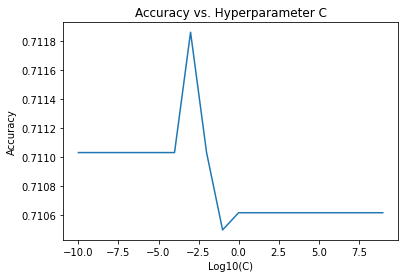

In [47]:
sns.lineplot(x=cs_log10,y=acc)
plt.xlabel('Log10(C)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Hyperparameter C')
plt.show()

<b>Analysis</b>: Which value of $C$ yields the best results, in terms of accuracy?

It seems that accuracy first increases as C increases and is optimized around Log10(C) = -3 which is C = 0.001, at which point accuracy takes a sudden drop and reach low levels as C increases.